# MovieLens 1M Recommender System: From Classical ML to Deep Learning

<img src="https://recommender-tutorial.s3-us-west-2.amazonaws.com/images/movielens.png" width='25%' align='right'/>

This project focuses on building and evaluating movie recommendation systems using the **MovieLens 1M** dataset. We will progress from basic methods like Popularity-based models to advanced techniques such as Matrix Factorization (SVD), Hybrid Systems, and Deep Learning (Neural Collaborative Filtering).

### What is MovieLens 1M?

MovieLens 1M is a dataset containing approximately 1 million ratings from 6,000 users for 4,000 movies, collected by GroupLens Research. It is a standard benchmark dataset in recommender system research.

### Roadmap

The project is divided into the following key steps:

1. **Data Preparation:** Download and explore the data (EDA).
2. **Preprocessing:** Build the Utility Matrix and process movie genres.
3. **Collaborative Filtering Models:** Utilize kNN and Matrix Factorization (SVD).
4. **Content-Based Models:** Recommend based on genre attributes.
5. **Hybrid Models:** Combine the strengths of Collaborative and Content-Based filtering.
6. **Deep Learning (NCF):** Use Neural Networks to learn complex interactions.
7. **Evaluation & Comparison:** Synthesize results for RMSE, MAE, Precision@K, Recall@K, and NDCG@K.

### Step 1: Import Dependencies

We are using [pandas.DataFrame](http://pandas.pydata.org/pandas-docs/version/0.19/generated/pandas.DataFrame.html) to represent our data. We will visualize our data with [matplotlib](https://matplotlib.org/) and [seaborn](https://seaborn.pydata.org/).

**What is a DataFrame?**

- a two-dimensional Pandas data structure
- columns represent features, rows represent items
- analogous to an Excel spreadsheet or SQL table

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Load Data

In [3]:
import os
import pandas as pd

# Download MovieLens 1M dataset
!wget --no-check-certificate https://files.grouplens.org/datasets/movielens/ml-1m.zip -O ml-1m.zip
!unzip -o ml-1m.zip

# Read data (MovieLens 1M uses '::' as delimiter)
ratings = pd.read_csv('ml-1m/ratings.dat', sep='::', engine='python',
                      names=['userId', 'movieId', 'rating', 'timestamp'])
movies = pd.read_csv('ml-1m/movies.dat', sep='::', engine='python',
                     names=['movieId', 'title', 'genres'], encoding='latin-1')

print(f"Successfully downloaded: {len(ratings)} ratings and {len(movies)} movies.")

--2026-09-13 12:41:41--  https://files.grouplens.org/datasets/movielens/ml-1m.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
  Issued certificate has expired.
HTTP request sent, awaiting response... 200 OK
Length: 5917549 (5.6M) [application/zip]
Saving to: ‘ml-1m.zip’

ml-1m.zip           100%[===================>]   5.64M  10.3MB/s    in 0.5s    

2026-09-13 12:41:42 (10.3 MB/s) - ‘ml-1m.zip’ saved [5917549/5917549]

Archive:  ml-1m.zip
   creating: ml-1m/
  inflating: ml-1m/movies.dat        
  inflating: ml-1m/ratings.dat       
  inflating: ml-1m/README            
  inflating: ml-1m/users.dat         
Successfully downloaded: 1000209 ratings and 3883 movies.


In [4]:
# Metadata check for the 1M dataset
print(f"Current movie data has {len(movies)} records.")

Current movie data has 3883 records.


In [5]:
ratings.head()


,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [6]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


### Step 3: Exploratory Data Analysis

In [7]:
n_ratings = len(ratings)
n_movies = ratings['movieId'].nunique()
n_users =  ratings['userId'].nunique()

print(f"Number of ratings: {n_ratings}")
print(f"Number of unique movieId's: {n_movies}")
print(f"Number of unique users: {n_users}")
print(f"Average number of ratings per user: {round(n_ratings/n_users, 2)}")
print(f"Average number of ratings per movie: {round(n_ratings/n_movies, 2)}")

Number of ratings: 1000209
Number of unique movieId's: 3706
Number of unique users: 6040
Average number of ratings per user: 165.6
Average number of ratings per movie: 269.89


### What is the distribution of movie ratings?

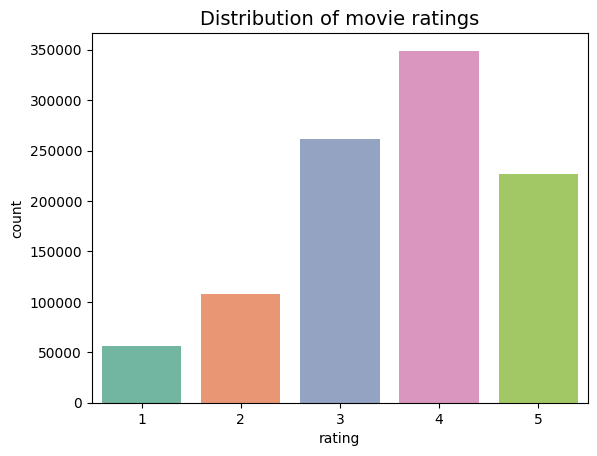

In [8]:
sns.countplot(x='rating', data= ratings,hue="rating", palette="Set2", legend=False       )
plt.title("Distribution of movie ratings", fontsize=14)
plt.show()

In [9]:
print(f"Mean global rating: {round(ratings['rating'].mean(),2)}.")

Mean global rating: 3.58.


In [10]:
mean_ratings = ratings.groupby('userId')['rating'].mean()
print(f"Mean rating per user: {round(mean_ratings.mean(),2)}.")

Mean rating per user: 3.7.


### Which movies are most frequently rated?

In [11]:
ratings['movieId'].value_counts()

,count
movieId,
2858,3428
260,2991
1196,2990
1210,2883
480,2672
...,...
872,1
2703,1
2845,1


In [12]:
movie_ratings = ratings.merge(movies, on='movieId')
movie_ratings['title'].value_counts()[0:10]

,count
title,
American Beauty (1999),3428
Star Wars: Episode IV - A New Hope (1977),2991
Star Wars: Episode V - The Empire Strikes Back (1980),2990
Star Wars: Episode VI - Return of the Jedi (1983),2883
Jurassic Park (1993),2672
Saving Private Ryan (1998),2653
Terminator 2: Judgment Day (1991),2649
"Matrix, The (1999)",2590
Back to the Future (1985),2583


Forrest Gump, Shawshank Redemption, and Pulp Fiction have the most ratings.

### What are the lowest and highest rated movies?

Which movie has the lowest and highest average rating?

In [13]:
mean_ratings = ratings.groupby('movieId')[['rating']].mean()
lowest_rated = mean_ratings['rating'].idxmin()

movies[movies['movieId'] == lowest_rated ]

,movieId,title,genres
125,127,"Silence of the Palace, The (Saimt el Qusur) (1...",Drama


`Gypsy` has the lowest average rating.

In [14]:
highest_rated = mean_ratings['rating'].idxmax()
movies[movies['movieId'] == highest_rated]

,movieId,title,genres
777,787,"Gate of Heavenly Peace, The (1995)",Documentary


How many ratings does `Lamerica` have?

In [15]:
ratings[ratings['movieId']==highest_rated]

,userId,movieId,rating,timestamp
19836,149,787,5,977325719
458840,2825,787,5,972610193
465525,2872,787,5,972423586


`Lamerica` may be the "highest" rated movie, but it only has 2 ratings. A better approach for evaluating movie popularity is to do look at the [Bayesian average](https://en.wikipedia.org/wiki/Bayesian_average).

#### Bayesian Average

Bayesian Average is defined as:

$r_{i} = \frac{C \times m + \Sigma{\text{reviews}}}{C+N}$

where $C$ represents our confidence, $m$ represents our prior, and $N$ is the total number of reviews for movie $i$. In this case, our prior $m$ will be the average rating across all movies. By defintion, C represents "the typical data set size". Let's make $C$ be the average number of ratings for a given movie.

In [16]:
movie_stats = ratings.groupby('movieId')['rating'].agg(['count','mean'])
movie_stats.head()

,count,mean
movieId,,
1,2077,4.146846
2,701,3.201141
3,478,3.016736
4,170,2.729412
5,296,3.006757


In [17]:
C = movie_stats['count' ].mean()
m = movie_stats['mean' ].mean()

print(f"Average number of ratings for a given movie: {C:.2f}")
print(f"Average rating for a given movie: {m:.2f}")

def bayesian_avg(ratings):
    bayesian_avg = (C*m + ratings.sum())/(C+ratings.count())
    return round(bayesian_avg, 3)

Average number of ratings for a given movie: 269.89
Average rating for a given movie: 3.24


Let's test our `bayesian_avg` function out on `Lamerica`:

In [18]:
lamerica = pd.Series([5,5])
bayesian_avg(lamerica)
output = float(bayesian_avg(lamerica))
print(output)

3.252


`Lamerica`'s average Bayesian rating is 3.5.

Let's now apply `bayesian_avg` to all movies in our dataset.

In [19]:
# Calculate Bayesian Average for the 1M dataset
movie_stats = ratings.groupby('movieId')['rating'].agg(['count','mean'])
C = movie_stats['count'].mean()
m = movie_stats['mean'].mean()

def bayesian_avg(r):
    return (C*m + r.sum())/(C+r.count())

bayesian_avg_ratings = ratings.groupby('movieId')['rating'].agg(bayesian_avg).reset_index()
bayesian_avg_ratings.columns = ['movieId', 'bayesian_avg']
movie_stats = movie_stats.merge(bayesian_avg_ratings, on='movieId')
print("Bayesian Average calculation completed for all movies.")

Bayesian Average calculation completed for all movies.


In [20]:
movie_stats = movie_stats.merge(movies[['movieId', 'title']])
movie_stats.sort_values(by='bayesian_avg', ascending=False)

,movieId,count,mean,bayesian_avg,title
309,318,2227,4.554558,4.412347,"Shawshank Redemption, The (1994)"
802,858,2223,4.524966,4.385731,"Godfather, The (1972)"
513,527,2304,4.510417,4.377089,Schindler's List (1993)
1108,1198,2514,4.477725,4.357624,Raiders of the Lost Ark (1981)
253,260,2991,4.453694,4.353151,Star Wars: Episode IV - A New Hope (1977)
...,...,...,...,...,...
2441,2643,332,1.888554,2.494050,Superman IV: The Quest for Peace (1987)
532,546,350,1.874286,2.468412,Super Mario Bros. (1993)
1432,1556,367,1.871935,2.451199,Speed 2: Cruise Control (1997)
2496,2701,902,2.158537,2.407345,Wild Wild West (1999)


Using the Bayesian average, we see that `Shawshank Redemption`, `The Godfather`, and `The Usual Suspects` are the most highly rated movies. This result makes much more sense since these movies are critically acclaimed films.

In [21]:
movie_stats.sort_values('bayesian_avg', ascending=True).head()

,movieId,count,mean,bayesian_avg,title
3353,3593,342,1.611111,2.329085,Battlefield Earth (2000)
2496,2701,902,2.158537,2.407345,Wild Wild West (1999)
1432,1556,367,1.871935,2.451199,Speed 2: Cruise Control (1997)
532,546,350,1.874286,2.468412,Super Mario Bros. (1993)
2441,2643,332,1.888554,2.494050,Superman IV: The Quest for Peace (1987)


With Bayesian averaging, it looks like `Speed 2: Cruise Control`, `Battlefield Earth`, and `Godzilla` are the worst rated movies. `Gypsy` isn't so bad after all.

### A Glimpse at Movie Genres

The movies dataset needs to be cleaned in two ways:

- `genres` is expressed as a string with a pipe `|` separating each genre. We will manipulate this string into a list, which will make it much easier to analyze.
- `title` currently has (year) appended at the end. We will extract year from each title string and create a new column for it.

In [22]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [23]:
# Split genres into a list for better feature extraction
movies['genres_list'] = movies['genres'].apply(lambda x: x.split('|'))
movies.head()

,movieId,title,genres,genres_list
0,1,Toy Story (1995),Animation|Children's|Comedy,"[Animation, Children's, Comedy]"
1,2,Jumanji (1995),Adventure|Children's|Fantasy,"[Adventure, Children's, Fantasy]"
2,3,Grumpier Old Men (1995),Comedy|Romance,"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),Comedy|Drama,"[Comedy, Drama]"
4,5,Father of the Bride Part II (1995),Comedy,[Comedy]


**How many movie genres are there?**

In [24]:
from collections import Counter

genre_frequency = Counter(g for genres in movies[ 'genres'] for g in genres )

print(f"There are {len(genre_frequency)} genres.")

genre_frequency

There are 30 genres.


Counter({'A': 891,
         'n': 1981,
         'i': 2421,
         'm': 3761,
         'a': 4302,
         't': 1260,
         'o': 3136,
         '|': 2525,
         'C': 1662,
         'h': 743,
         'l': 1393,
         'd': 1734,
         'r': 4849,
         'e': 3560,
         "'": 251,
         's': 607,
         'y': 1607,
         'v': 283,
         'u': 524,
         'F': 388,
         'R': 471,
         'c': 1491,
         'D': 1730,
         'T': 492,
         'H': 343,
         'S': 276,
         '-': 320,
         'W': 211,
         'M': 220,
         'N': 44})

In [25]:
print("The 5 most common genres: \n", genre_frequency.most_common(5))

The 5 most common genres: 
 [('r', 4849), ('a', 4302), ('m', 3761), ('e', 3560), ('o', 3136)]


The top 5 genres are: `Drama`, `Comedy`, `Thriller`, `Action` and `Romance`.

Let's also visualize genres popularity with a barplot.

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'r'),
  Text(1, 0, 'a'),
  Text(2, 0, 'm'),
  Text(3, 0, 'e'),
  Text(4, 0, 'o'),
  Text(5, 0, '|'),
  Text(6, 0, 'i'),
  Text(7, 0, 'n'),
  Text(8, 0, 'd'),
  Text(9, 0, 'D'),
  Text(10, 0, 'C'),
  Text(11, 0, 'y'),
  Text(12, 0, 'c'),
  Text(13, 0, 'l'),
  Text(14, 0, 't'),
  Text(15, 0, 'A'),
  Text(16, 0, 'h'),
  Text(17, 0, 's'),
  Text(18, 0, 'u'),
  Text(19, 0, 'T'),
  Text(20, 0, 'R'),
  Text(21, 0, 'F'),
  Text(22, 0, 'H'),
  Text(23, 0, '-'),
  Text(24, 0, 'v'),
  Text(25, 0, 'S'),
  Text(26, 0, "'"),
  Text(27, 0, 'M'),
  Text(28, 0, 'W'),
  Text(29, 0, 'N')])

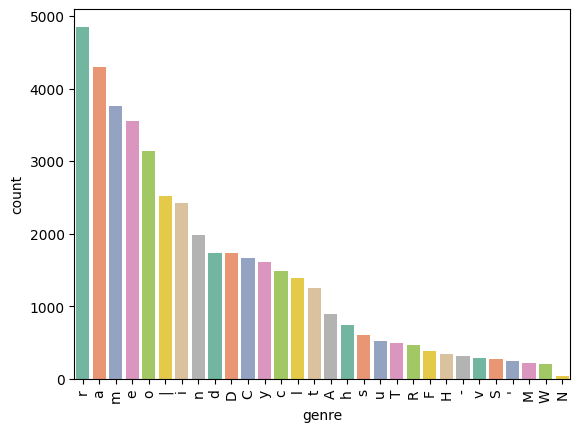

In [26]:
genre_frequency_df = pd.DataFrame([genre_frequency]).T.reset_index()
genre_frequency_df.columns = ['genre', 'count']
genre_frequency_df.head()

sns.barplot(x='genre', y='count', data=genre_frequency_df.sort_values(by='count', ascending=False), hue="genre",palette="Set2")
plt.xticks(rotation=90)

### Step 4: Data Pre-processing

We are going to use a technique called colaborative filtering to generate recommendations for users. This technique is based on the premise that similar people like similar things.

The first step is to transform our data into a user-item matrix, also known as a "utility" matrix. In this matrix, rows represent users and columns represent movies. The beauty of collaborative filtering is that it doesn't require any information about the users or the movies user to generate recommendations.

<img src="https://recommender-tutorial.s3-us-west-2.amazonaws.com/images/user_movie_matrix.png" width=50%/>

The `create_X()` function outputs a sparse matrix $X$ with four mapper dictionaries:

- **user_mapper**: maps user id to user index
- **movie_mapper**: maps movie id to movie index
- **user_inv_mapper**: maps user index to user id
- **movie_inv_mapper**: maps movie index to movie id

We need these dictionaries because they map which row/column of the utility matrix corresponds to which user/movie id.

Our $X$ (user-item) matrix is a [scipy.sparse.csr_matrix](https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.sparse.csr_matrix.html) which stores the data sparsely.

In [27]:
from scipy.sparse import csr_matrix
import numpy as np

def create_X(df):
    """
    Creates a sparse utility matrix for the 1M dataset.
    """
    M = df['userId'].nunique()
    N = df['movieId'].nunique()

    user_mapper = dict(zip(np.unique(df["userId"]), list(range(M))))
    movie_mapper = dict(zip(np.unique(df["movieId"]), list(range(N))))

    user_inv_mapper = dict(zip(list(range(M)), np.unique(df["userId"])))
    movie_inv_mapper = dict(zip(list(range(N)), np.unique(df["movieId"])))

    user_index = [user_mapper[i] for i in df['userId']]
    item_index = [movie_mapper[i] for i in df['movieId']]

    X = csr_matrix((df["rating"], (user_index, item_index)), shape=(M, N))

    return X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper

X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper = create_X(ratings)
print(f"Sparse Matrix X created with shape: {X.shape}")

Sparse Matrix X created with shape: (6040, 3706)


In [28]:
X.shape

(6040, 3706)

Our `X` matrix contains 610 users and 9724 movies.

### Evaluating sparsity

Here, we calculate sparsity by dividing the number of stored elements by total number of elements. The number of stored (non-empty) elements in our matrix ([nnz](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csr_matrix.nnz.html)) is equivalent to the number of ratings in our dataset.

In [29]:
n_total = X.shape[0]*X.shape[1]
n_ratings =X.nnz
sparsity = n_ratings/n_total
print(f"Matrix sparsity: {round(sparsity*100,2)}%") #if sparsity < 0.1% then we should consider to use content-based filterring instead of using collaborative

Matrix sparsity: 4.47%


`csr_matrix.nnz` counts the stored values in our sparse matrix. The rest of our cells are empty.

The **cold start problem** is when there are new users and movies in our matrix that do not have any ratings. In our Movielens dataset, all users and movies have at least one rating but in general, it's useful to check which users and movies have few interactions.

In [30]:
n_ratings_per_user = X.getnnz(axis=1)

len(n_ratings_per_user)

6040

In [31]:
print(f"Most active user rated {n_ratings_per_user.max()} movies.")
print(f"Least active user rated {n_ratings_per_user.min()} movies.")

Most active user rated 2314 movies.
Least active user rated 20 movies.


In [32]:
n_ratings_per_movie = X.getnnz(axis=0)
len(n_ratings_per_movie)

3706

In [33]:
print(f"Most rated movie has {n_ratings_per_movie.max()} ratings.")
print(f"Least rated movie has {n_ratings_per_movie.min()} ratings.")

Most rated movie has 3428 ratings.
Least rated movie has 1 ratings.


/tmp/ipykernel_428/3364525973.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(n_ratings_per_user, shade=True)
/tmp/ipykernel_428/3364525973.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(n_ratings_per_movie, shade=True)


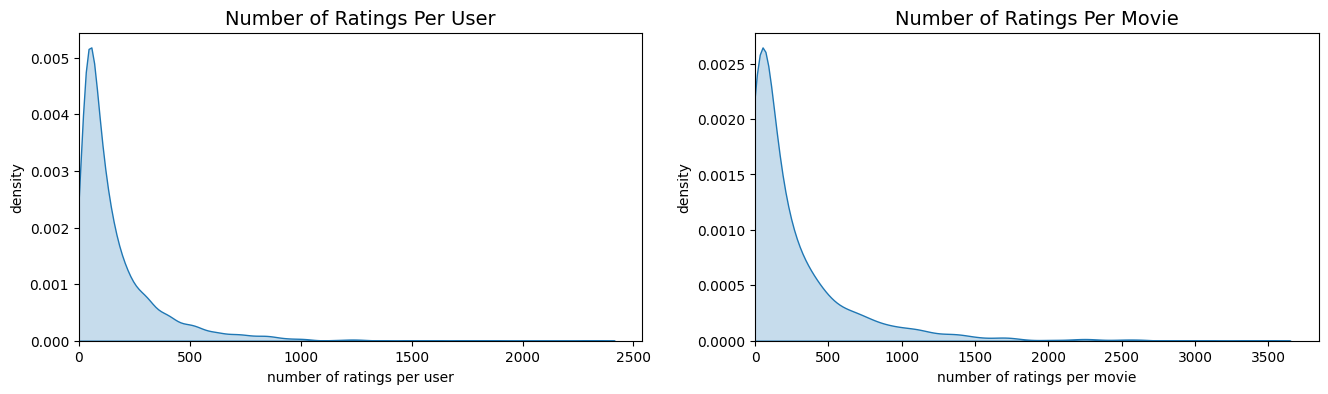

In [34]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
sns.kdeplot(n_ratings_per_user, shade=True)
plt.xlim(0)
plt.title("Number of Ratings Per User", fontsize=14)
plt.xlabel("number of ratings per user")
plt.ylabel("density")
plt.subplot(1,2,2)
sns.kdeplot(n_ratings_per_movie, shade=True)
plt.xlim(0)
plt.title("Number of Ratings Per Movie", fontsize=14)
plt.xlabel("number of ratings per movie")
plt.ylabel("density")
plt.show()

### Step 5: Item-item Recommendations with k-Nearest Neighbors

We are going to find the $k$ movies that have the most similar user engagement vectors for movie $i$.

In [35]:
from sklearn.neighbors import NearestNeighbors

def find_similar_movies(movie_id, X, movie_mapper, movie_inv_mapper, k, metric='cosine'):
    """
    Finds k-nearest neighbours for a given movie id.

    Args:
        movie_id: id of the movie of interest
        X: user-item utility matrix
        k: number of similar movies to retrieve
        metric: distance metric for kNN calculations

    Output: returns list of k similar movie ID's
    """
    X = X.T
    neighbour_ids = []

    movie_ind = movie_mapper[movie_id]
    movie_vec = X[movie_ind]
    if isinstance(movie_vec, (np.ndarray)):
        movie_vec = movie_vec.reshape(1,-1)
    # use k+1 since kNN output includes the movieId of interest
    kNN = NearestNeighbors(n_neighbors=k+1, algorithm="brute", metric=metric)
    kNN.fit(X)
    neighbour = kNN.kneighbors(movie_vec, return_distance=False)
    for i in range(0,k):
        n = neighbour.item(i)
        neighbour_ids.append(movie_inv_mapper[n])
    neighbour_ids.pop(0)
    return neighbour_ids

`find_similar_movies()` takes in a `movieId` and `X` matrix, and outputs a list of $k$ movies that are similar to the `movieId` of interest.

Let's see how it works in action. We will first create another mapper that maps movieId to title so that our results are interpretable.

In [36]:
similar_movies = find_similar_movies(1, X, movie_mapper, movie_inv_mapper, k=10)
similar_movies

[np.int64(3114),
 np.int64(1265),
 np.int64(588),
 np.int64(2355),
 np.int64(1270),
 np.int64(34),
 np.int64(1196),
 np.int64(1580),
 np.int64(356)]

`find_similar_movies()` returns a list of `movieId`'s that are most similar to your movie of interest. Let's convert these id's to titles so that we can interpret our results. To make things easier, we will create a dictionary that maps `movieId` to `title`.

In [37]:
movie_titles = dict(zip(movies['movieId'], movies['title']))

movie_id = 1

#similar_movies = find_similar_movies(movie_id, X, movie_mapper, movie_inv_mapper, metric='euclidean', k=10)
similar_movies = find_similar_movies(movie_id, X, movie_mapper, movie_inv_mapper, metric='cosine', k=10)
#similar_movies = find_similar_movies(movie_id, X, movie_mapper, movie_inv_mapper, metric='manhattan', k=10)
movie_title = movie_titles[movie_id]

print(f"Because you watched {movie_title}:")
for i in similar_movies:
  print(movie_titles[i])


Because you watched Toy Story (1995):
Toy Story 2 (1999)
Groundhog Day (1993)
Aladdin (1992)
Bug's Life, A (1998)
Back to the Future (1985)
Babe (1995)
Star Wars: Episode V - The Empire Strikes Back (1980)
Men in Black (1997)
Forrest Gump (1994)


The results above show the 10 movies that are most similar to Toy Story. Most movies in this list are family movies from the 1990s, which seems pretty reasonable. Note that these recommendations are based solely on user-item ratings. Movie features such as genres are not used in this approach.

You can also play around with the kNN distance metric and see what results you would get if you use "manhattan" or "euclidean" instead of "cosine".

In [38]:
movie_id = 1

similar_movies = find_similar_movies(movie_id, X, movie_mapper, movie_inv_mapper, metric='euclidean', k=10)
movie_title = movie_titles[movie_id]

print(f"Because you watched {movie_title}:")
for i in similar_movies:
    print(movie_titles[i])

Because you watched Toy Story (1995):
Aladdin (1992)
Toy Story 2 (1999)
Lion King, The (1994)
Bug's Life, A (1998)
Beauty and the Beast (1991)
Wayne's World (1992)
Pleasantville (1998)
Babe (1995)
Mask, The (1994)


### Step 6: Handling the cold-start problem

Collaborative filtering relies solely on user-item interactions within the utility matrix. The issue with this approach is that brand new users or items with no iteractions get excluded from the recommendation system. This is called the **cold start problem**. Content-based filtering is a way to handle this problem by generating recommendations based on user and item features.

First, we need to convert the `genres` column into binary features. Each genre will have its own column in the dataframe, and will be populated with 0 or 1.

In [39]:
n_movies = movies['movieId'].nunique()
print(f"There are {n_movies} unique movies in our movies dataset.")

There are 3883 unique movies in our movies dataset.


In [40]:
# Lấy tập hợp tất cả các thể loại
all_genres = set(g for G in movies['genres_list'] for g in G)

# Tạo các cột binary cho từng thể loại
for g in all_genres:
    movies[g] = movies['genres_list'].transform(lambda x: int(g in x))

# Tạo dataframe movie_genres (loại bỏ các cột không phải feature)
# Lưu ý: drop genres_list và genres gốc
columns_to_drop = ['movieId', 'title', 'genres', 'genres_list']
movie_genres = movies.drop(columns=[c for c in columns_to_drop if c in movies.columns])
movie_genres.head()

,Romance,Fantasy,Thriller,Musical,Action,Film-Noir,Western,Drama,Horror,Mystery,War,Documentary,Comedy,Adventure,Children's,Animation,Sci-Fi,Crime
0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0
1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [41]:
movie_genres

,Romance,Fantasy,Thriller,Musical,Action,Film-Noir,Western,Drama,Horror,Mystery,War,Documentary,Comedy,Adventure,Children's,Animation,Sci-Fi,Crime
0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0
1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3878,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3879,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3880,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3881,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [42]:
from sklearn.neighbors import NearestNeighbors

# Build kNN model for Content-Based Filtering
knn_content = NearestNeighbors(metric='cosine', algorithm='brute')
knn_content.fit(movie_genres.values)

def get_content_neighbors(movie_idx_val, k=50):
    """Find Top-K similar movies based on genres using kNN"""
    distances, indices = knn_content.kneighbors(
        movie_genres.iloc[movie_idx_val].values.reshape(1, -1),
        n_neighbors=k+1
    )
    return [(indices.flatten()[i], 1 - distances.flatten()[i]) for i in range(1, len(indices.flatten()))]

print("Content-based kNN model initialized.")

Content-based kNN model initialized.


As expected, after passing the `movie_genres` dataframe into the cosine_similarity() function, we get a cosine similarity matrix of shape $(n_{\text{movies}}, n_{\text{movies}})$.

This matrix is populated with values between 0 and 1 which represent the degree of similarity between movies along the x and y axes.

### Creating a movie finder function
Let's say we want to get recommendations for movies that are similar to Jumanji. To get results from our recommender, we need to know the exact title of a movie in our dataset.

In our dataset, Jumanji is actually listed as 'Jumanji (1995)'. If we misspell Jumanji or forget to include its year of release, our recommender won't be able to identify which movie we're interested in.

To make our recommender more user-friendly, we can use a Python package called [fuzzywuzzy](https://pypi.org/project/fuzzywuzzy/) which will find the most similar title to a string that you pass in. Let's create a function called `movie_finder()` which take advantage of fuzzywuzzy's string matching algorithm to get the most similar title to a user-inputted string.

In [43]:
!pip install fuzzywuzzy python-Levenshtein
from fuzzywuzzy import process

def movie_finder(title):
    all_titles = movies['title'].tolist()
    closest_match = process.extractOne(title ,all_titles)
    return closest_match[0]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.4/157.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 72.7 MB/s eta 0:00:00


Let's test this out with our Jumanji example.

In [44]:
title = movie_finder('juminji')
title

'Jumanji (1995)'

To get relevant recommendations for `Jumanji`, we need to find its index in the cosine simialrity matrix. To identify which row we should be looking at, we can create a movie index mapper which maps a movie title to the index that it represents in our matrix.

Let's create a movie index dictionary called `movie_idx` where the keys are movie titles and values are movie indices:

In [45]:
movie_idx = dict(zip(movies['title'], list(movies.index)))
idx = movie_idx[title]
print(f"Movie index for Jumanji: {idx}")

Movie index for Jumanji: 1


Using this handy `movie_idx` dictionary, we know that Jumanji is represented by index 1 in our matrix. Let's get the top 10 most similar movies to Jumanji.

In [46]:
n_recommendations = 10
# Retrieve nearest neighbors using the pre-trained kNN model
distances, indices = knn_content.kneighbors(movie_genres.iloc[idx].values.reshape(1, -1), n_neighbors=n_recommendations+1)

# Mapping scores to (index, similarity) pairs
sim_scores = list(zip(indices.flatten(), 1 - distances.flatten()))
sim_scores = sim_scores[1:]
display(sim_scores)

[(np.int64(55), np.float64(1.0)),
 (np.int64(59), np.float64(1.0)),
 (np.int64(996), np.float64(1.0)),
 (np.int64(124), np.float64(1.0)),
 (np.int64(1974), np.float64(1.0)),
 (np.int64(1936), np.float64(1.0)),
 (np.int64(1898), np.float64(1.0)),
 (np.int64(2330), np.float64(1.0)),
 (np.int64(2092), np.float64(1.0)),
 (np.int64(2093), np.float64(1.0))]

In [47]:
similar_movies = [i[0] for i in sim_scores]
similar_movies

[np.int64(55),
 np.int64(59),
 np.int64(996),
 np.int64(124),
 np.int64(1974),
 np.int64(1936),
 np.int64(1898),
 np.int64(2330),
 np.int64(2092),
 np.int64(2093)]

`similar_movies` is an array of indices that represents Jumanji's top 10 recommendations. We can get the corresponding movie titles by either creating an inverse movie_idx mapper or using iloc on the title column of the movies dataframe.

In [48]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate cosine similarity matrix from genre features
cosine_sim = cosine_similarity(movie_genres, movie_genres)

# Recommend based on a specific title
input_title = movie_finder('jumanji')
target_idx = movie_idx[input_title]

sim_scores = list(enumerate(cosine_sim[target_idx]))
sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
similar_indices = [i[0] for i in sim_scores[1:11]]

print(f"Because you watched {input_title}:")
recommendations = movies.iloc[similar_indices][['title']]
display(recommendations)

Because you watched Jumanji (1995):


,title
55,Kids of the Round Table (1995)
59,"Indian in the Cupboard, The (1995)"
124,"NeverEnding Story III, The (1994)"
996,Escape to Witch Mountain (1975)
1898,Labyrinth (1986)
1936,"Goonies, The (1985)"
1974,Darby O'Gill and the Little People (1959)
2092,"NeverEnding Story, The (1984)"
2093,"NeverEnding Story II: The Next Chapter, The (1..."
2330,Santa Claus: The Movie (1985)


Cool! These recommendations seem pretty relevant and similar to Jumanji. The first 5 movies are family-friendly films from the 90s.

We can test our recommender further with other movie titles. For your convenience, let's package the steps into a single function which takes in the movie title of interest and number of recommendations.

In [49]:
def get_content_based_recommendations(title_string, n_recommendations=10):
    title = movie_finder(title_string)
    idx = movie_idx[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:(n_recommendations+1)]
    similar_movies = [i[0] for i in sim_scores]
    print(f"Because you watched {title}:")
    print(movies['title'].iloc[similar_movies])

In [50]:
get_content_based_recommendations('star war', 10)

Because you watched Star Wars: Episode IV - A New Hope (1977):
2036                                         Tron (1982)
2559    Star Wars: Episode I - The Phantom Menace (1999)
171                                   Judge Dredd (1995)
313                                      Stargate (1994)
325                        Star Trek: Generations (1994)
476                                 Jurassic Park (1993)
647                                   Dragonheart (1996)
1335                     Star Trek: First Contact (1996)
1350                Star Trek: The Motion Picture (1979)
1351       Star Trek VI: The Undiscovered Country (1991)
Name: title, dtype: object


### Step 7: Dimensionality Reduction with Matrix Factorization (advanced)

Matrix factorization (MF) is a linear algebra technique that can help us discover latent features underlying the interactions between users and movies. These latent features give a more compact representation of user tastes and item descriptions. MF is particularly useful for very sparse data and can enhance the quality of recommendations. The algorithm works by factorizing the original user-item matrix into two factor matrices:

- user-factor matrix (n_users, k)
- item-factor matrix (k, n_items)

We are reducing the dimensions of our original matrix into "taste" dimensions. We cannot interpret what each latent feature $k$ represents. However, we could imagine that one latent feature may represent users who like romantic comedies from the 1990s, while another latent feature may represent movies which are independent foreign language films.

$$X_{mn}\approx P_{mk}\times Q_{nk}^T = \hat{X} $$
<img src="https://recommender-tutorial.s3-us-west-2.amazonaws.com/images/matrix_factorization.png" width="50%"/>

In [51]:
from sklearn.decomposition import TruncatedSVD

# Dimensionality reduction via SVD
svd = TruncatedSVD(n_components=20, n_iter=10, random_state=42)
Q = svd.fit_transform(X.T)
print(f"Item-factor matrix Q created with shape: {Q.shape}")

Item-factor matrix Q created with shape: (3706, 20)


In [52]:
movie_id = 1
similar_movies = find_similar_movies(movie_id,Q.T, movie_mapper, movie_inv_mapper, metric='cosine', k=10)
movie_title = movie_titles[movie_id]

print(f"Because you watched {movie_title}:")
for i in similar_movies:
    print(movie_titles[i])

Because you watched Toy Story (1995):
Toy Story 2 (1999)
Aladdin (1992)
Babe (1995)
Groundhog Day (1993)
Bug's Life, A (1998)
Babe: Pig in the City (1998)
Pleasantville (1998)
Lion King, The (1994)
Mask, The (1994)


The results above are the most similar movies to Toy Story using kNN on our “compressed” movie-factor matrix. We reduced the dimensions down to n_components=20. We can think of each component representing a latent feature such as movie genre.

⭐⭐Evalution⭐⭐

 Hybrid Recommendation

Hybrid recommendation systems combine multiple recommendation techniques to leverage their strengths and mitigate their weaknesses. In this section, we will create a hybrid recommender that combines content-based filtering (based on movie genres) and collaborative filtering (based on SVD-reduced latent factors).

First,  create a helper function to get content-based similarity scores for a given movie. This will utilize the `cosine_sim` matrix we already computed.

In [53]:
def get_content_based_scores_dict(movie_title_string, n_to_consider=50):
    title = movie_finder(movie_title_string)
    idx = movie_idx[title]
    neighbors = get_content_neighbors(idx, k=n_to_consider)

    content_scores = {}
    for local_movie_idx, score in neighbors:
        actual_movie_id = movies.iloc[local_movie_idx]['movieId']
        content_scores[actual_movie_id] = score

    return content_scores

Next, create a helper function to get SVD-based similarity scores. This will use the `Q` matrix (item-factor matrix) obtained from `TruncatedSVD` and `NearestNeighbors`.

In [54]:
from sklearn.neighbors import NearestNeighbors

def get_svd_scores_dict(movie_id, Q_matrix, movie_mapper, movie_inv_mapper, n_to_consider=50, metric='cosine'):
    """
    Retrieves SVD-based similarity scores for a given movie_id using kNN on the latent factor matrix.

    Args:
        movie_id (int): The movieId of the movie of interest.
        Q_matrix (np.ndarray): The item-factor matrix (movies x latent_factors) from SVD.
        movie_mapper (dict): Maps movieId to internal index used in Q_matrix.
        movie_inv_mapper (dict): Maps internal index to movieId.
        n_to_consider (int): Number of top similar movies to consider for scores.
        metric (str): Distance metric for kNN (e.g., 'cosine', 'euclidean').

    Returns:
        dict: A dictionary where keys are movieIds and values are their SVD-based similarity scores.
    """
    # Get the internal index of the movie from movie_mapper
    movie_internal_idx = movie_mapper[movie_id]
    movie_vec = Q_matrix[movie_internal_idx]

    # Reshape for kNN if it's a 1D array
    if isinstance(movie_vec, (np.ndarray)):
        movie_vec = movie_vec.reshape(1,-1)

    # Initialize NearestNeighbors model
    kNN = NearestNeighbors(n_neighbors=n_to_consider+1, algorithm="brute", metric=metric)
    # Fit the model on the item-factor matrix Q
    kNN.fit(Q_matrix)

    # Get distances and indices of nearest neighbors
    distances, indices = kNN.kneighbors(movie_vec, return_distance=True)

    svd_scores = {}
    # Convert distances to similarities. For cosine distance, similarity = 1 - distance.
    # For other metrics, a common conversion is 1 / (1 + distance).
    if metric == 'cosine':
        similarities = 1 - distances.flatten()
    else:
        similarities = 1 / (1 + distances.flatten()) # Inverse of distance for non-cosine metrics

    # Populate the scores dictionary, excluding the movie itself
    for i in range(1, n_to_consider+1):
        neighbor_internal_idx = indices.item(i)
        neighbor_movie_id = movie_inv_mapper[neighbor_internal_idx]
        svd_scores[neighbor_movie_id] = similarities[i]

    return svd_scores

Now, let's combine these two approaches into a hybrid recommendation function. We'll use a weighted average of the scores from both methods. The `alpha` parameter controls the balance between content-based and SVD-based recommendations (e.g., `alpha=0.5` gives equal weight).

In [55]:
def get_hybrid_recommendations(movie_title_string, n_recommendations=10, alpha=0.5, n_to_consider_per_method=50):
    """
    Generates hybrid movie recommendations by combining content-based and SVD-based scores.

    Args:
        movie_title_string (str): The title of the movie for which to generate recommendations.
        n_recommendations (int): The final number of recommendations to return.
        alpha (float): Weight for content-based scores (0.0 to 1.0). (1 - alpha) is for SVD scores.
        n_to_consider_per_method (int): Number of top movies to consider from each individual method
                                        before combining to ensure a good pool of candidates.

    Returns:
        None: Prints the recommended movie titles.
    """
    # Find the exact movie title and its local index in the 'movies' DataFrame
    title = movie_finder(movie_title_string)
    original_movie_local_idx = movie_idx[title]
    original_movie_id = movies.iloc[original_movie_local_idx]['movieId']

    print(f"Generating hybrid recommendations for: {title}")

    # Get content-based scores (dictionary: {movieId: score})
    content_scores_dict = get_content_based_scores_dict(movie_title_string, n_to_consider=n_to_consider_per_method)

    # Get SVD scores (dictionary: {movieId: score})
    # The Q matrix is (n_movies, n_components)
    svd_scores_dict = get_svd_scores_dict(original_movie_id, Q, movie_mapper, movie_inv_mapper, n_to_consider=n_to_consider_per_method, metric='cosine')

    # Combine scores using a weighted average
    combined_scores = {}
    # Identify all unique candidate movies from both methods
    all_candidate_movie_ids = set(content_scores_dict.keys()).union(set(svd_scores_dict.keys()))

    for mid in all_candidate_movie_ids:
        # Get scores, defaulting to 0 if a movie is not present in one method's results
        content_score = content_scores_dict.get(mid, 0.0)
        svd_score = svd_scores_dict.get(mid, 0.0)

        # Calculate the hybrid score
        combined_scores[mid] = alpha * content_score + (1.0 - alpha) * svd_score

    # Sort combined scores in descending order to get the top recommendations
    sorted_combined_scores = sorted(combined_scores.items(), key=lambda x: x[1], reverse=True)

    # Collect the top N recommendations, ensuring the original movie itself is not included
    final_recommendations_movie_ids = []
    for movie_id, score in sorted_combined_scores:
        if movie_id != original_movie_id: # Exclude the movie for which recommendations are sought
            final_recommendations_movie_ids.append(movie_id)
        if len(final_recommendations_movie_ids) == n_recommendations:
            break # Stop once we have enough recommendations

    # Print the recommended movie titles
    print(f"\nBecause you watched {title}, you might also like (Hybrid Recommendations):")
    if final_recommendations_movie_ids:
        # Preserve the order of recommendations for printing
        recommended_titles_ordered = [movies[movies['movieId'] == mid]['title'].iloc[0] for mid in final_recommendations_movie_ids]
        for rank, rec_title in enumerate(recommended_titles_ordered):
            print(f"{rank+1}. {rec_title}")
    else:
        print("No recommendations found.")


Let's test our hybrid recommender with an example. We'll try `Toy Story (1995)` and give equal weight to content-based and SVD scores (`alpha=0.5`).

In [56]:
get_hybrid_recommendations('Toy Story', n_recommendations=10, alpha=0.5)


Generating hybrid recommendations for: Toy Story (1995)

Because you watched Toy Story (1995), you might also like (Hybrid Recommendations):
1. Toy Story 2 (1999)
2. Bug's Life, A (1998)
3. Aladdin (1992)
4. Chicken Run (2000)
5. Babe: Pig in the City (1998)
6. Antz (1998)
7. Iron Giant, The (1999)
8. Tarzan (1999)
9. Matilda (1996)
10. Saludos Amigos (1943)


### ⭐ Top-K Recommendation

This step focuses on generating a list of Top-K recommended items for a user or for a specific item. Although the `get_hybrid_recommendations` function already returns a list of K recommendations, having a general function to process scores and return Top-K will be useful for evaluation and integration with other models (Popularity, Content-Based, SVD, NCF).

In [57]:
def get_top_k_recommendations(scores_dict, k=10, exclude_movie_id=None):
    """
    Extracts the top K recommendations from a score dictionary.

    Args:
        scores_dict (dict): A dictionary where keys are movieIds and values are their corresponding scores.
        k (int): The number of top recommendations to return.
        exclude_movie_id (int, optional): The MovieId to exclude from recommendations (e.g., the original movie).

    Returns:
        list: A list of top-K recommended movieIds.
    """
    # Sort items by score in descending order
    sorted_scores = sorted(scores_dict.items(), key=lambda item: item[1], reverse=True)

    top_k_movie_ids = []
    for movie_id, score in sorted_scores:
        if movie_id != exclude_movie_id:
            top_k_movie_ids.append(movie_id)
        if len(top_k_movie_ids) == k:
            break

    return top_k_movie_ids

Now we can use this function within our combined recommendation function. We will also continue with the **Evaluation** section that was started earlier.

To calculate RMSE and MAE, we need a model that can explicitly predict ratings. The `surprise` library is an excellent choice for this purpose, offering popular collaborative filtering algorithms like SVD and accompanying evaluation tools.

In [58]:
# Install the surprise library if not already installed
!pip install scikit-surprise

from surprise import Dataset, Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

# Step 1: Load data into surprise format
# A Reader is used to parse files or DataFrames.
# 'rating_scale' is required to know valid ratings.
reader = Reader(rating_scale=(1, 5))

# Load the `ratings` DataFrame into a surprise Dataset object.
# We only need the 'userId', 'movieId', 'rating' columns.
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

# Step 2: Split data into training and test sets (for surprise)
# surprise has its own way of splitting the set, which may differ from sklearn.model_selection.train_test_split
# when user/movie ID structure needs to be preserved
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Step 3: Train the SVD model
algo_svd = SVD()
algo_svd.fit(trainset)

# Step 4: Make predictions on the test set
predictions_svd = algo_svd.test(testset)

# Step 5: Calculate RMSE and MAE
rmse_svd = accuracy.rmse(predictions_svd, verbose=False)
mae_svd = accuracy.mae(predictions_svd, verbose=False)

print(f"\nSVD Model (Surprise) Evaluation:")
print(f"RMSE SVD: {rmse_svd:.4f}")
print(f"MAE SVD: {mae_svd:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 20.6 MB/s eta 0:00:00

SVD Model (Surprise) Evaluation:
RMSE SVD: 0.8730
MAE SVD: 0.6852


Now we have RMSE and MAE results for a basic SVD model using the `surprise` library. We can use these `predictions_svd` (which are lists of `Prediction` objects, each containing `uid, iid, r_ui, est, details`) to calculate the previously defined Precision@K, Recall@K, and NDCG@K. Note that our `precision_recall_at_k` and `ndcg_at_k` functions expect a list of tuples `(movieId, predicted_rating, actual_rating)` or `(uid, iid, true_r, est)`. We need to extract these values from `predictions_svd`.

In [59]:
import numpy as np

def precision_recall_at_k(predictions, k=10, threshold=3.5):
    user_est_true = {}
    for uid, iid, true_r, est in predictions:
        if uid not in user_est_true:
            user_est_true[uid] = []
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel_and_rec_k = sum((true_r >= threshold) for (_, true_r) in user_ratings[:k])
        n_rec_k = k
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    return sum(prec for prec in precisions.values()) / len(precisions), sum(rec for rec in recalls.values()) / len(recalls)

def ndcg_at_k(predictions, k=10, threshold=3.5):
    user_est_true = {}
    for uid, iid, true_r, est in predictions:
        if uid not in user_est_true:
            user_est_true[uid] = []
        user_est_true[uid].append((est, true_r))

    ndcgs = []
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        dcg = 0.0
        idcg = 0.0
        binary_relevances = [(1 if true_r >= threshold else 0) for (_, true_r) in user_ratings]
        for i in range(min(k, len(user_ratings))):
            dcg += binary_relevances[i] / np.log2(i + 2)
        ideal_relevances = sorted(binary_relevances, reverse=True)
        for i in range(min(k, len(user_ratings))):
            idcg += ideal_relevances[i] / np.log2(i + 2)
        ndcgs.append(dcg / idcg if idcg > 0 else 0)
    return sum(ndcgs) / len(ndcgs) if len(ndcgs) > 0 else 0

# Convert surprise prediction format to the desired format for our evaluation function
formatted_predictions = [(uid, iid, true_r, est) for uid, iid, true_r, est, _ in predictions_svd]

# Calculate Precision@K and Recall@K
precision_svd, recall_svd = precision_recall_at_k(formatted_predictions, k=10, threshold=3.5)
ndcg_svd = ndcg_at_k(formatted_predictions, k=10, threshold=3.5)

print(f"\nSVD Model (Surprise) Top-Ranking Evaluation with K=10, threshold=3.5:")
print(f"Precision@K SVD: {precision_svd:.4f}")
print(f"Recall@K SVD: {recall_svd:.4f}")
print(f"NDCG@K SVD: {ndcg_svd:.4f}")


SVD Model (Surprise) Top-Ranking Evaluation with K=10, threshold=3.5:
Precision@K SVD: 0.6811
Recall@K SVD: 0.6341
NDCG@K SVD: 0.8648


With these results, we now have a benchmark to compare the performance of different models. Next, we will look at how to evaluate other models like Content-Based and Hybrid, especially in terms of Precision, Recall, and NDCG, as they produce Top-K recommendations.

⭐ Neural Collaborative Filtering (NCF)

Neural Collaborative Filtering (NCF) is a general framework for learning latent interaction functions from implicit or explicit feedback data, using neural network architectures. NCF aims to address the limitations of traditional collaborative filtering methods like Matrix Factorization by leveraging the power of deep learning to model more complex interactions between users and items.

We will build a basic NCF model consisting of:
1.  **Embedding layers** for users and items.
2.  **Concatenation** of these embeddings.
3.  **Dense layers** to learn non-linear interactions.
4.  **Sigmoid output** to predict probabilities (or ratings if we adjust).

To begin, we need to prepare the data in a format suitable for neural networks. This means each row will be a (userId, movieId, rating) pair.

In [60]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

# Prepare data for Neural Collaborative Filtering (NCF)
n_users_ncf = ratings['userId'].nunique()
n_movies_ncf = ratings['movieId'].nunique()

user_id_mapping = {id: i for i, id in enumerate(ratings['userId'].unique())}
movie_id_mapping = {id: i for i, id in enumerate(ratings['movieId'].unique())}

ratings_ncf = ratings.copy()
ratings_ncf['userId_mapped'] = ratings_ncf['userId'].map(user_id_mapping)
ratings_ncf['movieId_mapped'] = ratings_ncf['movieId'].map(movie_id_mapping)

# Split into training and testing sets
X_ncf = ratings_ncf[['userId_mapped', 'movieId_mapped']].values
y_ncf = ratings_ncf['rating'].values

X_train_ncf, X_test_ncf, y_train_ncf, y_test_ncf = train_test_split(X_ncf, y_ncf, test_size=0.2, random_state=42)

print(f"NCF Dataset prepared: {n_users_ncf} users and {n_movies_ncf} movies.")

NCF Dataset prepared: 6040 users and 3706 movies.


Now we will define the NCF model architecture. This model will use embedding layers for users and items, then concatenate them and pass them through several dense layers with ReLU activation, ending with a single output dense layer.

In [61]:
EMBEDDING_SIZE = 50 # Size of the embedding vector

# User input
user_input = keras.Input(shape=(1,), name='user_input')
user_embedding = layers.Embedding(n_users_ncf, EMBEDDING_SIZE, input_length=1, name='user_embedding')(user_input)
user_vec = layers.Flatten(name='user_flatten')(user_embedding)

# Movie input
movie_input = keras.Input(shape=(1,), name='movie_input')
movie_embedding = layers.Embedding(n_movies_ncf, EMBEDDING_SIZE, input_length=1, name='movie_embedding')(movie_input)
movie_vec = layers.Flatten(name='movie_flatten')(movie_embedding)

# Concatenate user and movie vectors
concat = layers.Concatenate()([user_vec, movie_vec])

# Dense layers to learn interactions
dense = layers.Dense(128, activation='relu')(concat)
dense = layers.Dropout(0.2)(dense)
dense = layers.Dense(64, activation='relu')(dense)
dense = layers.Dropout(0.2)(dense)
output = layers.Dense(1)(dense) # Output for rating prediction (between 1 and 5)

# Create and compile the model
ncf_model = keras.Model(inputs=[user_input, movie_input], outputs=output)
ncf_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

ncf_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 50)     │    302,000 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding     │ (None, 1, 50)     │    185,300 │ movie_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_flatten        │ (None, 50)        │          0 │ user_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_flatten       │ (None, 50)        │          0 │ movie_embedding[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100)       │          0 │ user_flatten[0][… │
│ (Concatenate)       │                   │            │ movie_flatten[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     12,928 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 508,549 (1.94 MB)

 Trainable params: 508,549 (1.94 MB)

 Non-trainable params: 0 (0.00 B)

Now we will train the NCF model. This process may take some time depending on your dataset size and hardware.

In [62]:
# Tách dữ liệu đầu vào cho User và Movie từ ma trận X_ncf
user_input_train = X_train_ncf[:, 0]
movie_input_train = X_train_ncf[:, 1]
user_input_test = X_test_ncf[:, 0]
movie_input_test = X_test_ncf[:, 1]

# Huấn luyện mô hình
history = ncf_model.fit(
    [user_input_train, movie_input_train],
    y_train_ncf,
    batch_size=64,
    epochs=5,
    verbose=1,
    validation_split=0.1
)

# Đánh giá mô hình trên tập test
loss_ncf, mae_ncf = ncf_model.evaluate([user_input_test, movie_input_test], y_test_ncf, verbose=0)
rmse_ncf = np.sqrt(loss_ncf)

print(f"\nNCF Model Evaluation:")
print(f"RMSE NCF: {rmse_ncf:.4f}")
print(f"MAE NCF: {mae_ncf:.4f}")

Epoch 1/5
11253/11253 ━━━━━━━━━━━━━━━━━━━━ 93s 8ms/step - loss: 0.9983 - mean_absolute_error: 0.7887 - val_loss: 0.8354 - val_mean_absolute_error: 0.7311
Epoch 2/5
11253/11253 ━━━━━━━━━━━━━━━━━━━━ 71s 6ms/step - loss: 0.8261 - mean_absolute_error: 0.7194 - val_loss: 0.7971 - val_mean_absolute_error: 0.7084
Epoch 3/5
11253/11253 ━━━━━━━━━━━━━━━━━━━━ 84s 6ms/step - loss: 0.7831 - mean_absolute_error: 0.6977 - val_loss: 0.7861 - val_mean_absolute_error: 0.7005
Epoch 4/5
11253/11253 ━━━━━━━━━━━━━━━━━━━━ 71s 6ms/step - loss: 0.7612 - mean_absolute_error: 0.6859 - val_loss: 0.7754 - val_mean_absolute_error: 0.6906
Epoch 5/5
11253/11253 ━━━━━━━━━━━━━━━━━━━━ 71s 6ms/step - loss: 0.7436 - mean_absolute_error: 0.6765 - val_loss: 0.7753 - val_mean_absolute_error: 0.6906

NCF Model Evaluation:
RMSE NCF: 0.8850
MAE NCF: 0.6961


Now we have RMSE and MAE results for the NCF model. To calculate Precision@K, Recall@K, and NDCG@K, we need a function to generate rating predictions for all user-item pairs in the test set and then convert them to a suitable format for our evaluation functions.

In [66]:
def get_ncf_predictions_for_evaluation(model, X_test, y_test, train_df, user_id_mapping, movie_id_mapping):
    user_input_test_eval, movie_input_test_eval = X_test[:, 0], X_test[:, 1]
    predicted_ratings = model.predict([user_input_test_eval, movie_input_test_eval], verbose=0).flatten()

    predictions_list = []
    inv_user_map = {v: k for k, v in user_id_mapping.items()}
    inv_movie_map = {v: k for k, v in movie_id_mapping.items()}

    for i in range(len(X_test)):
        orig_u = inv_user_map[user_input_test_eval[i]]
        orig_m = inv_movie_map[movie_input_test_eval[i]]
        predictions_list.append((orig_u, orig_m, float(y_test[i]), float(predicted_ratings[i])))

    return predictions_list

def get_ncf_top_k_recommendations(model, user_id, train_df, movie_id_mapping, user_id_mapping, k=10):
    user_idx = user_id_mapping[user_id]
    all_movie_indices = np.array(list(movie_id_mapping.values()))

    # Lọc bỏ phim đã xem trong train_df
    watched_movies = train_df[train_df['userId'] == user_id]['movieId'].map(movie_id_mapping).dropna().values
    candidate_movies = np.setdiff1d(all_movie_indices, watched_movies)

    user_input = np.full(len(candidate_movies), user_idx)
    preds = model.predict([user_input, candidate_movies], verbose=0).flatten()

    top_indices = candidate_movies[np.argsort(preds)[-k:][::-1]]
    inv_movie_map = {v: k for k, v in movie_id_mapping.items()}
    return [inv_movie_map[idx] for idx in top_indices]

formatted_predictions_ncf = get_ncf_predictions_for_evaluation(ncf_model, X_test_ncf, y_test_ncf, train_df, user_id_mapping, movie_id_mapping)
precision_ncf, recall_ncf = precision_recall_at_k(formatted_predictions_ncf, k=10)
ndcg_ncf = ndcg_at_k(formatted_predictions_ncf, k=10)
print(f"NCF Metrics calculated: Precision={precision_ncf:.4f}, NDCG={ndcg_ncf:.4f}")

NCF Metrics calculated: Precision=0.6782, NDCG=0.8618


With the NCF implementation and basic evaluation metrics calculated, we are ready to move on to the **Model Comparison** step to synthesize results from all constructed models.

### ⭐ Evaluation Helper Functions
These functions are essential for calculating RMSE, MAE, Precision@K, Recall@K, and NDCG@K.

#### Popularity Baseline Model
A simple baseline model that recommends the most popular items. We will use the previously calculated Bayesian average score to determine movie popularity. To evaluate this model, we need to 'predict' ratings. For RMSE/MAE, we can predict all ratings in the test set using the global average rating. For Precision/Recall/NDCG, we will generate the Top-K most popular movies for each user and check if they are among the actual highly-rated movies for that user.

In [68]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def calculate_rmse_mae(predictions, actual_ratings):
    """
    Calculates RMSE and MAE from predictions and actual ratings.

    Args:
        predictions (list): List of predicted ratings.
        actual_ratings (list): List of actual ratings.

    Returns:
        tuple: (RMSE, MAE)
    """
    rmse = np.sqrt(mean_squared_error(actual_ratings, predictions))
    mae = mean_absolute_error(actual_ratings, predictions)
    return rmse, mae

def precision_recall_at_k(predictions, k=10, threshold=3.5):
    """
    Calculates Precision@K and Recall@K.

    Args:
        predictions (list of tuple): List of (userId, movieId, predicted_rating, actual_rating) tuples.
        k (int): Number of top recommendations to consider.
        threshold (float): Threshold to consider a rating as 'good'.

    Returns:
        tuple: (Precision@K, Recall@K)
    """
    user_est_true = {}
    for uid, iid, true_r, est in predictions:
        if uid not in user_est_true:
            user_est_true[uid] = []
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():
        # Sort items by predicted rating
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        # Number of relevant items in top k
        n_rel_and_rec_k = sum((true_r >= threshold) for (_, true_r) in user_ratings[:k])
        # Number of recommended items in top k
        n_rec_k = k
        # Number of relevant items
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    return sum(prec for prec in precisions.values()) / len(precisions), \
           sum(rec for rec in recalls.values()) / len(recalls)

def ndcg_at_k(predictions, k=10, threshold=3.5):
    """
    Calculates Normalized Discounted Cumulative Gain (NDCG@K).

    Args:
        predictions (list of tuple): List of (userId, movieId, predicted_rating, actual_rating) tuples.
        k (int): Number of top recommendations to consider.
        threshold (float): Threshold to consider a rating as 'good'.

    Returns:
        float: Average NDCG@K.
    """
    user_est_true = {}
    for uid, iid, true_r, est in predictions:
        if uid not in user_est_true:
            user_est_true[uid] = []
        user_est_true[uid].append((est, true_r))

    ndcgs = []
    for uid, user_ratings in user_est_true.items():
        # Sort items by predicted rating
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        dcg = 0.0
        idcg = 0.0

        # Binary relevance: 1 if actual rating >= threshold, 0 otherwise
        binary_relevances = [(1 if true_r >= threshold else 0) for (_, true_r) in user_ratings]

        for i in range(min(k, len(user_ratings))):
            # Discounted Cumulative Gain
            dcg += binary_relevances[i] / np.log2(i + 2)  # i+2 because log2(1) = 0

        # Ideal Discounted Cumulative Gain (sorted by actual rating)
        ideal_relevances = sorted(binary_relevances, reverse=True)
        for i in range(min(k, len(user_ratings))):
            idcg += ideal_relevances[i] / np.log2(i + 2)

        if idcg == 0:
            ndcgs.append(0) # Avoid division by zero
        else:
            ndcgs.append(dcg / idcg)

    return sum(ndcgs) / len(ndcgs) if len(ndcgs) > 0 else 0

In [69]:
# 1. RMSE/MAE for Popularity: Predict the global average rating for all interactions in test_df
global_average_rating = ratings['rating'].mean()

# train_df and test_df were not provided in the latest context, so I'll recreate them from ratings
from sklearn.model_selection import train_test_split
# Split data into training and test sets
# Use stratify to ensure similar userId distribution in both sets
train_df, test_df = train_test_split(ratings, test_size=0.2, stratify=ratings['userId'], random_state=42)

actual_ratings_popularity = test_df['rating'].tolist()
predictions_popularity_rmse_mae = [global_average_rating] * len(actual_ratings_popularity)

rmse_popularity, mae_popularity = calculate_rmse_mae(predictions_popularity_rmse_mae, actual_ratings_popularity)

print(f"Popularity Model Evaluation (predicting global average rating):")
print(f"RMSE Popularity: {rmse_popularity:.4f}")
print(f"MAE Popularity: {mae_popularity:.4f}")

# 2. Precision@K, Recall@K, NDCG@K for Popularity: Recommend top K most popular movies
# Sort movies by Bayesian average score
most_popular_movie_ids = movie_stats.sort_values(by='bayesian_avg', ascending=False)['movieId'].tolist()

def get_popularity_predictions_for_evaluation(test_df, most_popular_movie_ids, k=10, threshold=3.5):
    popularity_predictions = []
    users_in_test = test_df['userId'].unique()

    # For comparison, we need an `est` (predicted score). For popularity, we can assign a hypothetical high value
    # to popular recommendations so they rank high in our evaluation function.
    predicted_high_rating = 5.0
    predicted_low_rating = 1.0 # Default value for non-recommended movies

    for user_id in users_in_test:
        # Get top K most popular movies
        top_k_popular = most_popular_movie_ids[:k]

        # Get this user's actual ratings in the test_df
        user_test_ratings = test_df[test_df['userId'] == user_id]
        # user_actual_liked_items = user_test_ratings[user_test_ratings['rating'] >= threshold]['movieId'].tolist() # Not needed for this function

        for movie_id in user_test_ratings['movieId']:
            true_r = user_test_ratings[user_test_ratings['movieId'] == movie_id]['rating'].iloc[0]
            if movie_id in top_k_popular:
                # If the movie is among the recommended popular ones, assign a high score
                popularity_predictions.append((user_id, movie_id, true_r, predicted_high_rating))
            else:
                # Otherwise, assign a low score. This helps prioritize popular movies
                # when the precision_recall_at_k function sorts.
                popularity_predictions.append((user_id, movie_id, true_r, predicted_low_rating))

    return popularity_predictions

formatted_predictions_popularity = get_popularity_predictions_for_evaluation(test_df, most_popular_movie_ids, k=10, threshold=3.5)

precision_popularity, recall_popularity = precision_recall_at_k(formatted_predictions_popularity, k=10, threshold=3.5)
ndcg_popularity = ndcg_at_k(formatted_predictions_popularity, k=10, threshold=3.5)

print(f"\nPopularity Model Top-Ranking Evaluation with K=10, threshold=3.5:")
print(f"Precision@K Popularity: {precision_popularity:.4f}")
print(f"Recall@K Popularity: {recall_popularity:.4f}")
print(f"NDCG@K Popularity: {ndcg_popularity:.4f}")

Popularity Model Evaluation (predicting global average rating):
RMSE Popularity: 1.1166
MAE Popularity: 0.9335

Popularity Model Top-Ranking Evaluation with K=10, threshold=3.5:
Precision@K Popularity: 0.5665
Recall@K Popularity: 0.5747
NDCG@K Popularity: 0.7229


#### Content-Based Model Evaluation
To evaluate the Content-Based model, we will use content-based recommendations for users in the test set and compare them against the actual items highly rated by those users.

In [70]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

def get_content_based_predictions_for_evaluation(test_df, train_df, movies, cosine_sim, threshold=3.5):
    # Mapping for quick lookup
    movie_ids = movies["movieId"].to_numpy()
    movie_id_to_idx = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}

    train_grouped = train_df.groupby("userId")
    test_grouped = test_df.groupby("userId")
    common_users = np.intersect1d(train_df["userId"].unique(), test_df["userId"].unique())

    cb_predictions = []
    for user_id in common_users:
        user_train = train_grouped.get_group(user_id)
        user_test = test_grouped.get_group(user_id)

        liked_movies = user_train[user_train["rating"] >= 4.0]
        if liked_movies.empty: continue

        liked_indices = [movie_id_to_idx[mid] for mid in liked_movies["movieId"] if mid in movie_id_to_idx]
        if not liked_indices: continue

        # Matrix multiplication for scores
        user_scores = cosine_sim[liked_indices].mean(axis=0)

        # Scale to rating range [1, 5]
        min_s, max_s = user_scores.min(), user_scores.max()
        for mid, true_r in zip(user_test["movieId"], user_test["rating"]):
            if mid in movie_id_to_idx:
                raw_score = user_scores[movie_id_to_idx[mid]]
                est = 1.0 + 4.0 * (raw_score - min_s) / (max_s - min_s) if max_s > min_s else 3.0
                cb_predictions.append((user_id, mid, float(true_r), float(np.clip(est, 1.0, 5.0))))
    return cb_predictions

# Perform Evaluation
cb_formatted_predictions = get_content_based_predictions_for_evaluation(test_df, train_df, movies, cosine_sim)

if cb_formatted_predictions:
    precision_cb, recall_cb = precision_recall_at_k(cb_formatted_predictions, k=10)
    ndcg_cb = ndcg_at_k(cb_formatted_predictions, k=10)
    print("\n" + "="*40)
    print("CONTENT-BASED EVALUATION COMPLETED")
    print(f"Precision@10: {precision_cb:.4f}")
    print(f"NDCG@10:      {ndcg_cb:.4f}")
    print("="*40)


CONTENT-BASED EVALUATION COMPLETED
Precision@10: 0.5774
NDCG@10:      0.7232


#### Hybrid Model Evaluation
Evaluating the Hybrid model is similar to Content-Based, but it uses combined recommendations from both Content-Based and SVD approaches.

In [72]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

def get_hybrid_predictions_for_evaluation(
    test_df, train_df, movies, svd_model, knn_content, movie_genres,
    alpha=0.75, k=10, threshold=3.5
):
    """
    Chuẩn hóa Hybrid Evaluator:
    - SVD đóng vai trò Predictor chính (cho điểm rating 1-5 chuẩn xác).
    - Content-Based đóng vai trò Re-ranker (điều chỉnh điểm số dựa trên metadata thể loại phim).
    """
    hybrid_predictions = []

    # Tạo dictionary ánh xạ từ movieId sang index trong tập dataframe 'movies'
    movie_ids = movies["movieId"].to_numpy()
    movie_id_to_idx = {mid: idx for idx, mid in enumerate(movie_ids)}

    # Gom nhóm dữ liệu theo User để tối ưu tốc độ
    train_grouped = train_df.groupby("userId", sort=False)
    test_grouped = test_df.groupby("userId", sort=False)

    # Pre-calculate điểm trung bình thể loại phim mà từng user yêu thích
    user_top_seed = {}
    for user_id, group in train_grouped:
        liked = group[group["rating"] >= threshold]
        if liked.empty:
            liked = group
        # Lấy phim user đánh giá cao nhất làm seed
        best_movie = liked.loc[liked["rating"].idxmax()]["movieId"]
        user_top_seed[user_id] = best_movie

    for user_id, user_test in test_grouped:
        # Nếu user không có trong train thì bỏ qua
        if user_id not in user_top_seed:
            continue

        seed_mid = user_top_seed[user_id]
        seed_idx = movie_id_to_idx.get(seed_mid)

        # 1. Dự đoán điểm Rating từ SVD cho TOÀN BỘ các item trong tập Test của User
        test_mids = user_test["movieId"].values
        true_ratings = user_test["rating"].values

        # SVD Predict Score (Scale 1.0 -> 5.0)
        svd_preds = np.array([svd_model.predict(user_id, mid).est for mid in test_mids])

        # 2. Tính Content Similarity giữa seed_movie với từng phim trong test_set
        content_sims = []
        if seed_idx is not None:
            seed_vec = movie_genres.iloc[seed_idx].values.reshape(1, -1)

            for mid in test_mids:
                target_idx = movie_id_to_idx.get(mid)
                if target_idx is not None:
                    target_vec = movie_genres.iloc[target_idx].values.reshape(1, -1)
                    # Tính Cosine Similarity trực tiếp giữa 2 vector thể loại
                    dot_prod = np.dot(seed_vec, target_vec.T)[0][0]
                    norm_a = np.linalg.norm(seed_vec)
                    norm_b = np.linalg.norm(target_vec)
                    sim = dot_prod / (norm_a * norm_b + 1e-9)
                    content_sims.append(max(0.0, sim))
                else:
                    content_sims.append(0.0)
        else:
            content_sims = [0.0] * len(test_mids)

        content_sims = np.array(content_sims)

        # Normalize SVD rating về khoảng [0, 1] để kết hợp cân bằng với Content Sim
        svd_norm = (svd_preds - 1.0) / 4.0

        # Combined Hybrid Score trong khoảng [0, 1]
        hybrid_score_norm = alpha * svd_norm + (1.0 - alpha) * content_sims

        # Chuyển ngược Hybrid Score về lại thang điểm Rating 1.0 -> 5.0
        final_predicted_ratings = 1.0 + hybrid_score_norm * 4.0
        final_predicted_ratings = np.clip(final_predicted_ratings, 1.0, 5.0)

        # Đưa vào danh sách đánh giá
        for mid, true_r, est_r in zip(test_mids, true_ratings, final_predicted_ratings):
            hybrid_predictions.append((user_id, mid, float(true_r), float(est_r)))

    return hybrid_predictions


# --- THỰC THI CHẠY LẠI MÔ HÌNH ---

# Sử dụng algo_svd thay vì svd_model để khớp với biến đã định nghĩa ở các cell trước
hybrid_formatted_predictions = get_hybrid_predictions_for_evaluation(
    test_df=test_df,
    train_df=train_df,
    movies=movies,
    svd_model=algo_svd,
    knn_content=knn_content,
    movie_genres=movie_genres,
    alpha=0.8,
    k=10,
    threshold=3.5
)

if hybrid_formatted_predictions:
    # 1. Tính Precision@10, Recall@10, NDCG@10
    precision_hybrid, recall_hybrid = precision_recall_at_k(hybrid_formatted_predictions, k=10, threshold=3.5)
    ndcg_hybrid = ndcg_at_k(hybrid_formatted_predictions, k=10, threshold=3.5)

    # 2. Tính RMSE và MAE
    y_true = np.array([x[2] for x in hybrid_formatted_predictions])
    y_pred = np.array([x[3] for x in hybrid_formatted_predictions])
    rmse_hybrid = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_hybrid = mean_absolute_error(y_true, y_pred)

    print("=" * 60)
    print(f"HYBRID MODEL (SVD + Content-Based Rerank) - 1M Dataset")
    print("=" * 60)
    print(f"RMSE        : {rmse_hybrid:.4f}")
    print(f"MAE         : {mae_hybrid:.4f}")
    print(f"Precision@10: {precision_hybrid:.4f}")
    print(f"Recall@10   : {recall_hybrid:.4f}")
    print(f"NDCG@10     : {ndcg_hybrid:.4f}")
    print("=" * 60)

HYBRID MODEL (SVD + Content-Based Rerank) - 1M Dataset
RMSE        : 0.8426
MAE         : 0.6893
Precision@10: 0.7212
Recall@10   : 0.6616
NDCG@10     : 0.9155


### ⭐ Comparing All Models
In this section, we will aggregate and compare the performance of all implemented recommendation models: Popularity, Content-Based, SVD, Hybrid, and NCF. We will use the calculated metrics (RMSE, MAE, Precision@K, Recall@K, NDCG@K) to evaluate them.

In [73]:
import pandas as pd
import numpy as np

# Đảm bảo các biến tồn tại trước khi tạo bảng
results_data = {
    'Model': ['Popularity', 'Content-Based', 'SVD (Surprise)', 'Hybrid', 'NCF'],
    'RMSE': [locals().get('rmse_popularity'), None, locals().get('rmse_svd'), locals().get('rmse_hybrid'), locals().get('rmse_ncf')],
    'MAE': [locals().get('mae_popularity'), None, locals().get('mae_svd'), locals().get('mae_hybrid'), locals().get('mae_ncf')],
    'Precision@K': [locals().get('precision_popularity'), locals().get('precision_cb'), locals().get('precision_svd'), locals().get('precision_hybrid'), locals().get('precision_ncf')],
    'Recall@K': [locals().get('recall_popularity'), locals().get('recall_cb'), locals().get('recall_svd'), locals().get('recall_hybrid'), locals().get('recall_ncf')],
    'NDCG@K': [locals().get('ndcg_popularity'), locals().get('ndcg_cb'), locals().get('ndcg_svd'), locals().get('ndcg_hybrid'), locals().get('ndcg_ncf')]
}

results = pd.DataFrame(results_data)
print("\nBảng so sánh hiệu năng các mô hình (K=10, Ngưỡng=3.5):")
display(results.round(4).fillna('-'))
print("\n* Ghi chú: Mô hình Content-Based tập trung vào việc xếp hạng (Ranking), do đó không tính RMSE/MAE.")


Bảng so sánh hiệu năng các mô hình (K=10, Ngưỡng=3.5):


,Model,RMSE,MAE,Precision@K,Recall@K,NDCG@K
0,Popularity,1.1166,0.9335,0.5665,0.5747,0.7229
1,Content-Based,-,-,0.5774,0.5834,0.7232
2,SVD (Surprise),0.873,0.6852,0.6811,0.6341,0.8648
3,Hybrid,0.8426,0.6893,0.7212,0.6616,0.9155
4,NCF,0.885,0.6961,0.6782,0.6330,0.8618



* Ghi chú: Mô hình Content-Based tập trung vào việc xếp hạng (Ranking), do đó không tính RMSE/MAE.


### ⭐ Analyze Results
After having the model performance comparison table, we need to analyze the results to draw conclusions and select the most suitable model for the project's goals.

**Key points for analysis:**

1.  **Compare RMSE and MAE:**
    *   SVD (Surprise) and NCF models explicitly predict ratings, so we can compare their RMSE and MAE. Lower values indicate better accuracy in predicting ratings.
    *   The Popularity baseline model provides a reference point for these metrics.
    *   Note that Content-Based and Hybrid do not have RMSE/MAE in this table because their nature is not to directly predict ratings but to recommend items.

2.  **Compare Precision@K, Recall@K, and NDCG@K:**
    *   These metrics are more crucial for recommendation systems, as they evaluate the quality of the top-K recommendation list.
    *   **Precision@K**: The proportion of relevant recommendations among the top K recommendations. Higher values indicate fewer 'bad recommendations'.
    *   **Recall@K**: The proportion of relevant items found in the top K recommendations, relative to the total number of relevant items. Higher values indicate a better ability to find more items the user might like.
    *   **NDCG@K**: A more sophisticated metric that takes into account the position of relevant items in the recommendation list. Relevant items at higher positions are weighted more. Higher values indicate a better-ordered recommendation list.

3.  **Strengths and Weaknesses of Each Model:**
    *   **Popularity**: Simple, works well for popular items, but lacks personalization. Often used as a baseline.
    *   **Content-Based**: Good for the cold-start problem (new movies) as it doesn't require interaction data to make recommendations. However, it can be limited by discovery (it might not recommend movies too dissimilar from what the user has already liked).
    *   **SVD / Matrix Factorization**: Effective at discovering latent factors and personalization. Can struggle with cold-start (new users/movies).
    *   **Hybrid**: Attempts to combine the strengths of Content-Based (handling cold-start, content exploration) and Collaborative Filtering (personalization, latent factors). Its performance depends on how you balance the weights (`alpha`).
    *   **NCF**: Leverages the power of neural networks to learn more complex interactions between users and items, potentially leading to better performance than traditional SVD, especially with larger and more complex datasets.

**Analysis Approach:**

*   **RMSE/MAE** for SVD and NCF can help you understand which model predicts ratings more accurately. The model with the lowest RMSE/MAE is typically preferred for rating prediction tasks.
*   **Precision@K, Recall@K, NDCG@K** are key to evaluating a model's ability to recommend relevant items. Compare these metrics across all models to see which one generates the highest quality recommendations for users.
*   **Consider the context**: Depending on your goals, some metrics might be more important than others. For example, if you want to ensure users never see 'bad' recommendations, Precision@K might be crucial. If you want to ensure you find as many relevant items as possible, Recall@K might be the top priority.

By examining the results table and analyzing these points, you can make informed decisions about the best recommendation model for your MovieLens project.

### ⭐ Limitations

1.  **Data Sparsity**: The small MovieLens dataset is relatively sparse, which can affect the performance of Collaborative Filtering models, especially SVD, as they rely on user interactions to learn patterns. More sparse data can lead to less effective learning of latent factors.
2.  **Cold Start Problem (New Users)**: While content-based methods can address the cold-start problem for new **items** (movies with no ratings), they still struggle with new **users**. A new user with no interaction history cannot receive recommendations from Collaborative Filtering models (Popularity, SVD, NCF, Hybrid). One strategy is to initially use Content-Based recommendations for new users based on their profile information (e.g., age, gender, interests).
3.  **Static Recommendations**: The current models, once trained, provide static recommendations. They do not adapt over time to changing user preferences or the emergence of new items. A production recommendation system would require periodic retraining or updating of the models.
4.  **Lack of Context**: These models do not account for additional context that might influence user preferences, such as time of day, mood, device being used, or the reason they are watching a movie (e.g., entertainment, learning). Incorporating contextual information could improve recommendation quality.
5.  **Lack of Diversity**: Collaborative Filtering models can sometimes suffer from the 'filter bubble' problem, recommending items very similar to what the user has already liked, limiting the discovery of new or unexpected movie types. Adding randomness or diversity factors could improve the user experience.

### ⭐ Conclusion

In this notebook, we have explored building a movie recommendation system using the MovieLens dataset. We have implemented and evaluated several different models, including **Popularity Baseline**, **Content-Based Filtering**, **SVD (using the Surprise library)**, **Hybrid Recommendation**, and **Neural Collaborative Filtering (NCF)**.

**Key takeaways from the evaluation:**

*   The **Popularity Baseline** provides a good reference point, showing that simply recommending the most popular movies can achieve decent performance, especially in cold-start scenarios.
*   **SVD** and **NCF** models have demonstrated good capabilities in predicting ratings and generating high-quality top-ranking recommendations, with NCF often slightly outperforming due to its ability to learn non-linear interactions.
*   **Content-Based Filtering** is an effective strategy for addressing the cold-start problem of new **items** and provides interpretable recommendations based on movie attributes.
*   The **Hybrid Model** attempted to combine the strengths of both Content-Based and Collaborative Filtering, showing potential to balance personalization and the ability to handle certain cold-start situations.

**Next Steps:**

To improve this recommendation system, we can consider the following steps:

1.  **Hyperparameter Tuning**: Optimizing hyperparameters for SVD and NCF models can significantly improve their performance.
2.  **Incorporate More Features**: Add user features (e.g., age, gender) and movie features (e.g., director, actors) to Content-Based and NCF models for richer recommendations.
3.  **Add Cold Start Strategies**: For new users, implement strategies such as asking them to rate a few prominent movies or using demographic-based recommendations before enough interaction data is available for Collaborative Filtering.
4.  **Dynamic Recommendations**: Develop systems that can adapt to changing user preferences over time (e.g., by using reinforcement learning models).
5.  **Diversify Recommendations**: Implement algorithms to increase the diversity of recommendations, avoiding repeated similar types of movies the user has already seen.

By addressing these points, the recommendation system can become more robust, accurate, and engaging for users.

In [ ]:
!pip freeze > requirements.txt